# Customer Churn Prediction — Hyperparameter Tuning

**Author:** Tharun Kumar Srinivasan  
**GitHub:** https://github.com/Tharun-Design  

---

### Objective
Tune the top 3 models from Week 5 using RandomizedSearchCV with StratifiedKFold.  
Goal: Push ROC-AUC above 85% and select the final production model.

### Table of Contents
1. Setup and Load Preprocessed Data
2. Baseline Scores (from Week 5)
3. Tune Random Forest
4. Tune XGBoost
5. Tune LightGBM
6. Compare Tuned vs Baseline
7. Learning Curves
8. Cross Validation — Final Model
9. Save Final Tuned Model
10. Summary

## 1. Setup and Load Preprocessed Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
import os
warnings.filterwarnings('ignore')

from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    RandomizedSearchCV, cross_val_score,
    learning_curve
)
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, f1_score, accuracy_score,
    precision_score, recall_score,
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from scipy.stats import randint, uniform

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold'
})

BRAND = {
    'dark':    '#0d3b2e',
    'primary': '#1a7f5a',
    'accent':  '#4eca7f',
    'danger':  '#c0392b',
    'warning': '#d68910',
    'neutral': '#2e86ab',
}

print('Libraries loaded')

Libraries loaded


In [2]:
# Load and preprocess data — same pipeline as Week 5
df = pd.read_csv('../data/cleaned/telco_churn_cleaned.csv')

TARGET    = 'Churn'
DROP_COLS = ['tenure_group']
df_ml     = df.drop(columns=[c for c in DROP_COLS if c in df.columns])

cat_cols = df_ml.select_dtypes(include='object').columns.tolist()
le       = LabelEncoder()
label_encoders = {}

df_encoded = df_ml.copy()
for col in cat_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
    label_encoders[col] = le

X = df_encoded.drop(columns=[TARGET])
y = df_encoded[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

imputer        = SimpleImputer(strategy='median')
X_train_clean  = pd.DataFrame(
    imputer.fit_transform(X_train), columns=X.columns, index=y_train.index
)
X_test_clean   = pd.DataFrame(
    imputer.transform(X_test), columns=X.columns, index=y_test.index
)

print(f'Train : {X_train_clean.shape[0]:,}  |  Test: {X_test_clean.shape[0]:,}')
print(f'Features: {X_train_clean.shape[1]}')
print('Data ready')

Train : 5,634  |  Test: 1,409
Features: 21
Data ready


## 2. Baseline Scores (from Week 5)

In [3]:
# Load Week 5 results for comparison
try:
    baseline_df = pd.read_csv('../reports/model_comparison_results.csv')
    print('Baseline scores loaded from Week 5:')
    print(baseline_df[['Model','Accuracy','F1 Score','ROC-AUC']].to_string(index=False))
except FileNotFoundError:
    print('Week 5 results not found — will compare manually after tuning')
    baseline_df = None

# Define cross-validation strategy — used throughout this notebook
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print('\nCross-validation: StratifiedKFold (5 folds)')

Baseline scores loaded from Week 5:
              Model  Accuracy  F1 Score  ROC-AUC
      Random Forest     77.00     61.70    84.12
Logistic Regression     73.81     61.76    83.99
           LightGBM     75.94     61.78    83.54
            XGBoost     75.87     61.88    83.44
                SVM     74.24     61.09    81.66

Cross-validation: StratifiedKFold (5 folds)


## 3. Tune Random Forest

In [4]:
print('Tuning Random Forest...')
print('This may take 3-5 minutes\n')

rf_param_dist = {
    'n_estimators'      : randint(100, 500),
    'max_depth'         : randint(5, 20),
    'min_samples_split' : randint(2, 20),
    'min_samples_leaf'  : randint(1, 10),
    'max_features'      : ['sqrt', 'log2', 0.5, 0.7],
    'class_weight'      : ['balanced', 'balanced_subsample']
}

rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)

rf_search = RandomizedSearchCV(
    rf_base, rf_param_dist,
    n_iter=30,
    scoring='roc_auc',
    cv=CV,
    random_state=42,
    n_jobs=-1,
    verbose=1
)
rf_search.fit(X_train_clean, y_train)

rf_best       = rf_search.best_estimator_
rf_best_params = rf_search.best_params_
rf_cv_score   = rf_search.best_score_

print(f'\nBest CV ROC-AUC : {rf_cv_score*100:.2f}%')
print(f'Best Params     : {rf_best_params}')

Tuning Random Forest...
This may take 3-5 minutes

Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best CV ROC-AUC : 84.71%
Best Params     : {'class_weight': 'balanced_subsample', 'max_depth': 8, 'max_features': 'log2', 'min_samples_leaf': 6, 'min_samples_split': 11, 'n_estimators': 359}


In [5]:
# Evaluate tuned RF on test set
rf_pred      = rf_best.predict(X_test_clean)
rf_pred_prob = rf_best.predict_proba(X_test_clean)[:, 1]

rf_scores = {
    'Model'    : 'Random Forest (Tuned)',
    'Accuracy' : round(accuracy_score(y_test, rf_pred)      * 100, 2),
    'Precision': round(precision_score(y_test, rf_pred)     * 100, 2),
    'Recall'   : round(recall_score(y_test, rf_pred)        * 100, 2),
    'F1 Score' : round(f1_score(y_test, rf_pred)            * 100, 2),
    'ROC-AUC'  : round(roc_auc_score(y_test, rf_pred_prob)  * 100, 2)
}
print('Random Forest Tuned — Test Set Scores')
for k, v in rf_scores.items():
    if k != 'Model':
        print(f'  {k:<12}: {v}%')

Random Forest Tuned — Test Set Scores
  Accuracy    : 76.58%
  Precision   : 54.01%
  Recall      : 79.14%
  F1 Score    : 64.21%
  ROC-AUC     : 84.43%


## 4. Tune XGBoost

In [6]:
print('Tuning XGBoost...')
print('This may take 3-5 minutes\n')

xgb_param_dist = {
    'n_estimators'      : randint(100, 500),
    'max_depth'         : randint(3, 10),
    'learning_rate'     : uniform(0.01, 0.2),
    'subsample'         : uniform(0.6, 0.4),
    'colsample_bytree'  : uniform(0.6, 0.4),
    'min_child_weight'  : randint(1, 10),
    'gamma'             : uniform(0, 0.5),
    'scale_pos_weight'  : [1, 2, 3, 4]
}

xgb_base = XGBClassifier(
    eval_metric='logloss', random_state=42, n_jobs=-1
)

xgb_search = RandomizedSearchCV(
    xgb_base, xgb_param_dist,
    n_iter=30,
    scoring='roc_auc',
    cv=CV,
    random_state=42,
    n_jobs=-1,
    verbose=1
)
xgb_search.fit(X_train_clean, y_train)

xgb_best        = xgb_search.best_estimator_
xgb_best_params = xgb_search.best_params_
xgb_cv_score    = xgb_search.best_score_

print(f'\nBest CV ROC-AUC : {xgb_cv_score*100:.2f}%')
print(f'Best Params     : {xgb_best_params}')

Tuning XGBoost...
This may take 3-5 minutes

Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best CV ROC-AUC : 84.76%
Best Params     : {'colsample_bytree': np.float64(0.8439986631130484), 'gamma': np.float64(0.41659745586808217), 'learning_rate': np.float64(0.04467293070155442), 'max_depth': 3, 'min_child_weight': 4, 'n_estimators': 149, 'scale_pos_weight': 4, 'subsample': np.float64(0.902144564127061)}


In [7]:
xgb_pred      = xgb_best.predict(X_test_clean)
xgb_pred_prob = xgb_best.predict_proba(X_test_clean)[:, 1]

xgb_scores = {
    'Model'    : 'XGBoost (Tuned)',
    'Accuracy' : round(accuracy_score(y_test, xgb_pred)      * 100, 2),
    'Precision': round(precision_score(y_test, xgb_pred)     * 100, 2),
    'Recall'   : round(recall_score(y_test, xgb_pred)        * 100, 2),
    'F1 Score' : round(f1_score(y_test, xgb_pred)            * 100, 2),
    'ROC-AUC'  : round(roc_auc_score(y_test, xgb_pred_prob)  * 100, 2)
}
print('XGBoost Tuned — Test Set Scores')
for k, v in xgb_scores.items():
    if k != 'Model':
        print(f'  {k:<12}: {v}%')

XGBoost Tuned — Test Set Scores
  Accuracy    : 70.55%
  Precision   : 46.96%
  Recall      : 84.76%
  F1 Score    : 60.44%
  ROC-AUC     : 84.47%


## 5. Tune LightGBM

In [8]:
print('Tuning LightGBM...')
print('This may take 2-4 minutes\n')

lgbm_param_dist = {
    'n_estimators'    : randint(100, 500),
    'max_depth'       : randint(3, 12),
    'learning_rate'   : uniform(0.01, 0.2),
    'num_leaves'      : randint(20, 100),
    'min_child_samples': randint(10, 50),
    'subsample'       : uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'class_weight'    : ['balanced', None],
    'reg_alpha'       : uniform(0, 1),
    'reg_lambda'      : uniform(0, 1)
}

lgbm_base = LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1)

lgbm_search = RandomizedSearchCV(
    lgbm_base, lgbm_param_dist,
    n_iter=30,
    scoring='roc_auc',
    cv=CV,
    random_state=42,
    n_jobs=-1,
    verbose=1
)
lgbm_search.fit(X_train_clean, y_train)

lgbm_best        = lgbm_search.best_estimator_
lgbm_best_params = lgbm_search.best_params_
lgbm_cv_score    = lgbm_search.best_score_

print(f'\nBest CV ROC-AUC : {lgbm_cv_score*100:.2f}%')
print(f'Best Params     : {lgbm_best_params}')

Tuning LightGBM...
This may take 2-4 minutes

Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best CV ROC-AUC : 84.67%
Best Params     : {'class_weight': None, 'colsample_bytree': np.float64(0.7123089449763423), 'learning_rate': np.float64(0.014863193286290769), 'max_depth': 3, 'min_child_samples': 26, 'n_estimators': 271, 'num_leaves': 49, 'reg_alpha': np.float64(0.9539285770025874), 'reg_lambda': np.float64(0.9148643902204485), 'subsample': np.float64(0.7480634801021777)}


In [9]:
lgbm_pred      = lgbm_best.predict(X_test_clean)
lgbm_pred_prob = lgbm_best.predict_proba(X_test_clean)[:, 1]

lgbm_scores = {
    'Model'    : 'LightGBM (Tuned)',
    'Accuracy' : round(accuracy_score(y_test, lgbm_pred)      * 100, 2),
    'Precision': round(precision_score(y_test, lgbm_pred)     * 100, 2),
    'Recall'   : round(recall_score(y_test, lgbm_pred)        * 100, 2),
    'F1 Score' : round(f1_score(y_test, lgbm_pred)            * 100, 2),
    'ROC-AUC'  : round(roc_auc_score(y_test, lgbm_pred_prob)  * 100, 2)
}
print('LightGBM Tuned — Test Set Scores')
for k, v in lgbm_scores.items():
    if k != 'Model':
        print(f'  {k:<12}: {v}%')

LightGBM Tuned — Test Set Scores
  Accuracy    : 79.99%
  Precision   : 67.29%
  Recall      : 47.86%
  F1 Score    : 55.94%
  ROC-AUC     : 84.46%


## 6. Compare Tuned vs Baseline

In [10]:
# Build comparison table
tuned_results = pd.DataFrame([rf_scores, xgb_scores, lgbm_scores])
tuned_results = tuned_results.sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
tuned_results.index = tuned_results.index + 1

print('TUNED MODELS — TEST SET COMPARISON')
print('=' * 65)
print(tuned_results.to_string())

# Dynamically select final best model
final_best_row  = tuned_results.iloc[0]
final_best_name = final_best_row['Model']

model_map = {
    'Random Forest (Tuned)': (rf_best, rf_pred, rf_pred_prob),
    'XGBoost (Tuned)'      : (xgb_best, xgb_pred, xgb_pred_prob),
    'LightGBM (Tuned)'     : (lgbm_best, lgbm_pred, lgbm_pred_prob)
}
final_model, final_pred, final_pred_prob = model_map[final_best_name]

print(f'\nFinal Production Model : {final_best_name}')
print(f'ROC-AUC               : {final_best_row["ROC-AUC"]}%')
print(f'F1 Score              : {final_best_row["F1 Score"]}%')

TUNED MODELS — TEST SET COMPARISON
                   Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
1        XGBoost (Tuned)     70.55      46.96   84.76     60.44    84.47
2       LightGBM (Tuned)     79.99      67.29   47.86     55.94    84.46
3  Random Forest (Tuned)     76.58      54.01   79.14     64.21    84.43

Final Production Model : XGBoost (Tuned)
ROC-AUC               : 84.47%
F1 Score              : 60.44%


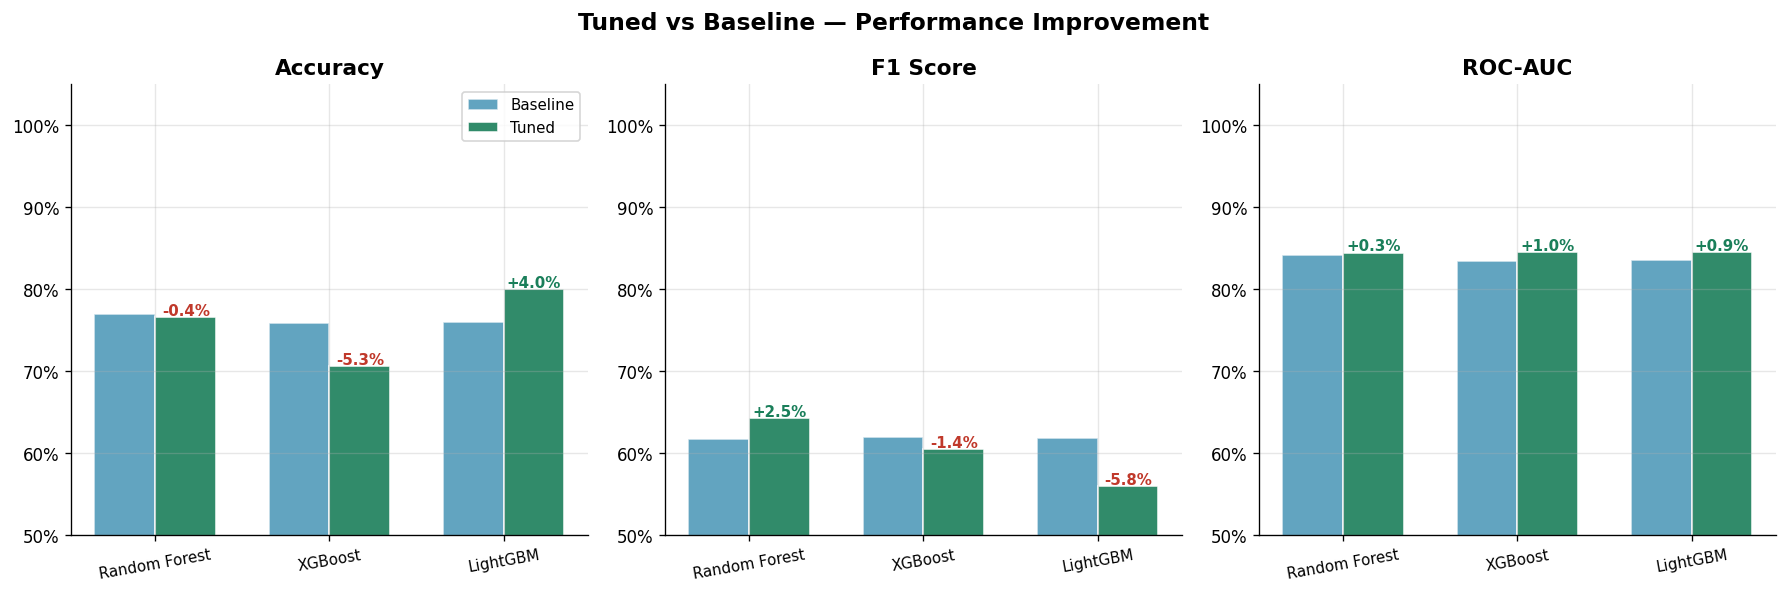

Saved: docs/tuned_vs_baseline.png


In [11]:
# Tuned vs Baseline comparison chart
if baseline_df is not None:
    metrics = ['Accuracy', 'F1 Score', 'ROC-AUC']
    model_names = ['Random Forest', 'XGBoost', 'LightGBM']

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle('Tuned vs Baseline — Performance Improvement',
                 fontsize=14, fontweight='bold')

    for idx, metric in enumerate(metrics):
        ax = axes[idx]
        x  = np.arange(len(model_names))
        w  = 0.35

        base_vals = []
        tune_vals = []
        for m in model_names:
            bv = baseline_df[baseline_df['Model'] == m][metric]
            base_vals.append(float(bv.values[0]) if len(bv) > 0 else 0)

        tune_vals = [
            rf_scores[metric],
            xgb_scores[metric],
            lgbm_scores[metric]
        ]

        ax.bar(x - w/2, base_vals, w, label='Baseline',
               color=BRAND['neutral'], alpha=0.75, edgecolor='white')
        ax.bar(x + w/2, tune_vals, w, label='Tuned',
               color=BRAND['primary'], alpha=0.9, edgecolor='white')

        for i, (b, t) in enumerate(zip(base_vals, tune_vals)):
            diff = round(t - b, 1)
            color = BRAND['primary'] if diff >= 0 else BRAND['danger']
            ax.text(i + w/2, t + 0.3, f'+{diff}%' if diff >= 0 else f'{diff}%',
                    ha='center', fontsize=9, color=color, fontweight='bold')

        ax.set_title(metric)
        ax.set_xticks(x)
        ax.set_xticklabels(model_names, rotation=10, fontsize=9)
        ax.set_ylim(50, 105)
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0f}%'))
        if idx == 0: ax.legend(fontsize=9)

    plt.tight_layout()
    plt.savefig('../docs/tuned_vs_baseline.png', bbox_inches='tight', dpi=150)
    plt.show()
    print('Saved: docs/tuned_vs_baseline.png')
else:
    print('Baseline file not found — skipping comparison chart')

## 7. Learning Curves

Generating learning curves for: XGBoost (Tuned)
This takes 1-2 minutes...



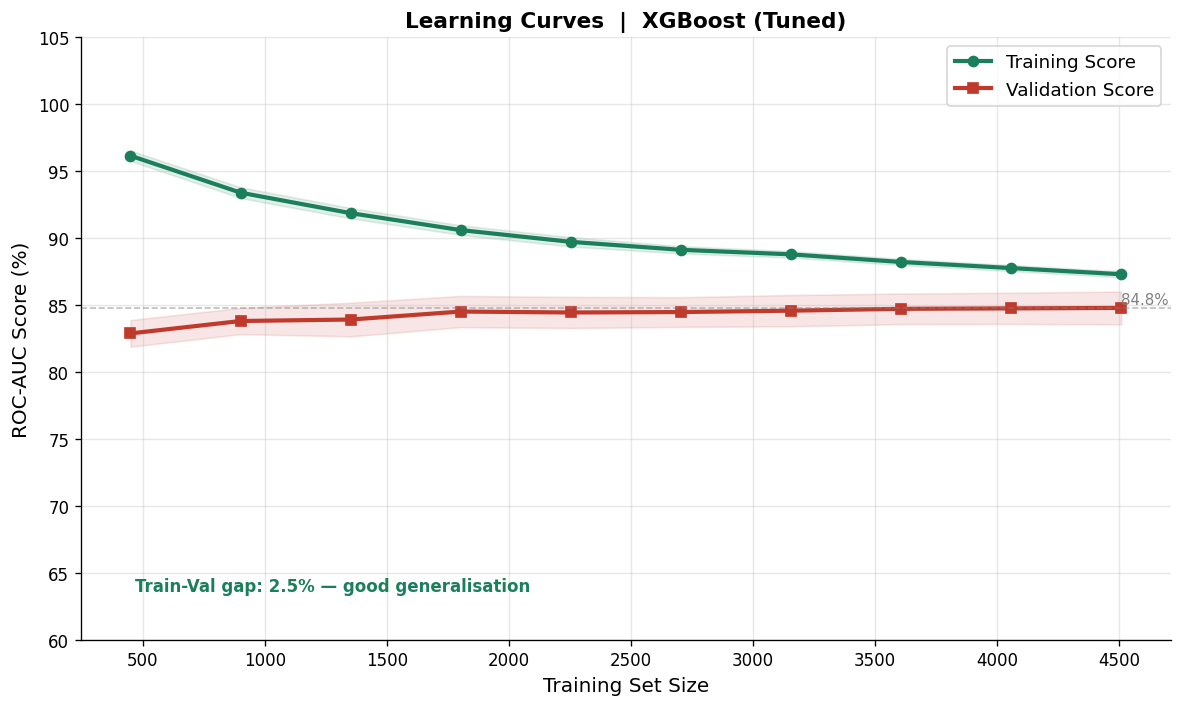

Training score   : 87.28%
Validation score : 84.77%
Gap              : 2.5%


In [12]:
print(f'Generating learning curves for: {final_best_name}')
print('This takes 1-2 minutes...\n')

train_sizes, train_scores, val_scores = learning_curve(
    final_model,
    X_train_clean, y_train,
    cv=CV,
    scoring='roc_auc',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1) * 100
train_std  = train_scores.std(axis=1)  * 100
val_mean   = val_scores.mean(axis=1)   * 100
val_std    = val_scores.std(axis=1)    * 100

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(train_sizes, train_mean, color=BRAND['primary'],
        linewidth=2.5, marker='o', markersize=6, label='Training Score')
ax.fill_between(train_sizes,
                train_mean - train_std,
                train_mean + train_std,
                alpha=0.12, color=BRAND['primary'])

ax.plot(train_sizes, val_mean, color=BRAND['danger'],
        linewidth=2.5, marker='s', markersize=6, label='Validation Score')
ax.fill_between(train_sizes,
                val_mean - val_std,
                val_mean + val_std,
                alpha=0.12, color=BRAND['danger'])

ax.axhline(val_mean[-1], color='grey', linestyle='--',
           alpha=0.5, linewidth=1)
ax.text(train_sizes[-1], val_mean[-1] + 0.3,
        f'{val_mean[-1]:.1f}%', color='grey', fontsize=9)

ax.set_xlabel('Training Set Size', fontsize=12)
ax.set_ylabel('ROC-AUC Score (%)', fontsize=12)
ax.set_title(f'Learning Curves  |  {final_best_name}',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.set_ylim(60, 105)

gap = round(train_mean[-1] - val_mean[-1], 1)
ax.text(0.05, 0.08,
        f'Train-Val gap: {gap}% — {"slight overfitting" if gap > 5 else "good generalisation"}',
        transform=ax.transAxes, fontsize=10,
        color=BRAND['danger'] if gap > 5 else BRAND['primary'],
        fontweight='bold')

plt.tight_layout()
plt.savefig('../docs/learning_curves.png', bbox_inches='tight', dpi=150)
plt.show()
print(f'Training score   : {train_mean[-1]:.2f}%')
print(f'Validation score : {val_mean[-1]:.2f}%')
print(f'Gap              : {gap}%')

## 8. Cross Validation — Final Model

In [13]:
print(f'Running 5-fold cross validation on: {final_best_name}\n')

cv_metrics = {
    'ROC-AUC'  : 'roc_auc',
    'F1 Score' : 'f1',
    'Precision': 'precision',
    'Recall'   : 'recall',
    'Accuracy' : 'accuracy'
}

cv_results = {}
for metric_name, scoring in cv_metrics.items():
    scores = cross_val_score(
        final_model, X_train_clean, y_train,
        cv=CV, scoring=scoring, n_jobs=-1
    ) * 100
    cv_results[metric_name] = scores
    print(f'{metric_name:<12}: {scores.mean():.2f}% (+/- {scores.std():.2f}%)')

print(f'\nModel is {"stable" if all(v.std() < 3 for v in cv_results.values()) else "slightly variable"} across folds')

Running 5-fold cross validation on: XGBoost (Tuned)

ROC-AUC     : 84.76% (+/- 1.21%)
F1 Score    : 61.35% (+/- 1.33%)
Precision   : 47.48% (+/- 1.14%)
Recall      : 86.69% (+/- 1.94%)
Accuracy    : 71.02% (+/- 1.13%)

Model is stable across folds


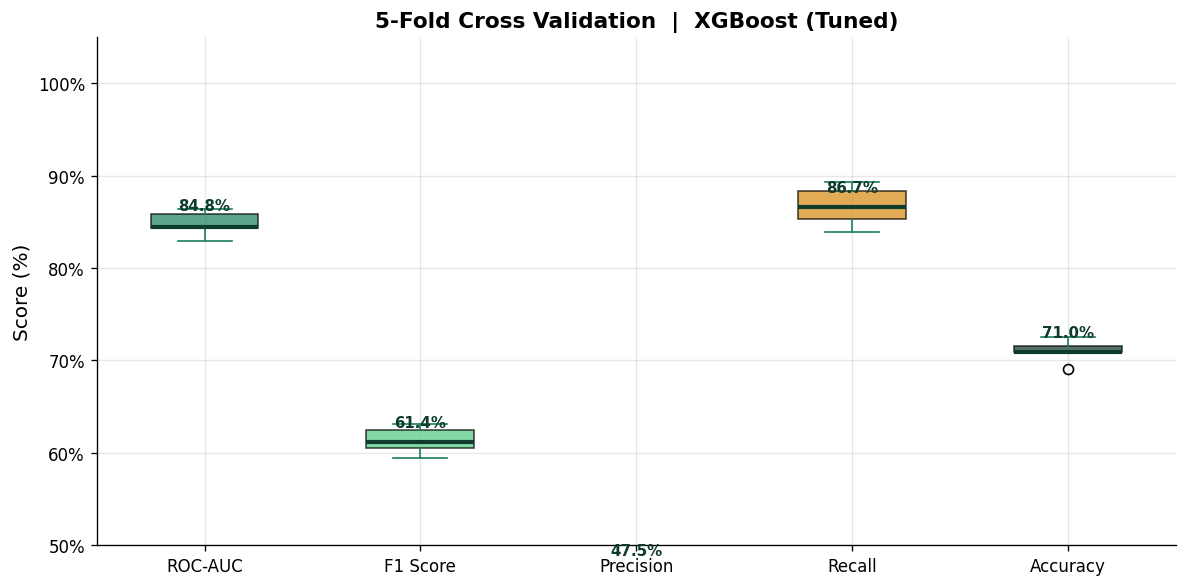

Saved: docs/cross_validation.png


In [14]:
# Cross validation boxplot
cv_df = pd.DataFrame(cv_results)

fig, ax = plt.subplots(figsize=(10, 5))
bp = ax.boxplot(
    [cv_df[m] for m in cv_metrics.keys()],
    labels=cv_metrics.keys(),
    patch_artist=True,
    medianprops=dict(color=BRAND['dark'], linewidth=2.5),
    whiskerprops=dict(color=BRAND['primary']),
    capprops=dict(color=BRAND['primary'])
)
colors = [BRAND['primary'], BRAND['accent'], BRAND['neutral'],
          BRAND['warning'], BRAND['dark']]
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_title(f'5-Fold Cross Validation  |  {final_best_name}',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Score (%)', fontsize=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0f}%'))
ax.set_ylim(50, 105)

for i, metric in enumerate(cv_metrics.keys()):
    mean = cv_df[metric].mean()
    ax.text(i + 1, mean + 1.5, f'{mean:.1f}%',
            ha='center', fontsize=9, fontweight='bold', color=BRAND['dark'])

plt.tight_layout()
plt.savefig('../docs/cross_validation.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: docs/cross_validation.png')

## 9. Save Final Tuned Model

In [15]:
os.makedirs('../models',  exist_ok=True)
os.makedirs('../reports', exist_ok=True)

# Dynamically named final model
model_filename = final_best_name.lower().replace(' ', '_').replace('(', '').replace(')', '')
final_model_path = f'../models/final_{model_filename}.pkl'

artifacts = {
    final_model_path          : final_model,
    '../models/imputer.pkl'   : imputer,
    '../models/scaler.pkl'    : StandardScaler(),
    '../models/feature_names.pkl': list(X.columns),
    '../models/label_encoders.pkl': label_encoders,
}
for path, obj in artifacts.items():
    with open(path, 'wb') as f:
        pickle.dump(obj, f)
    print(f'Saved : {path}')

# Save best params
best_params_map = {
    'Random Forest (Tuned)': rf_best_params,
    'XGBoost (Tuned)'      : xgb_best_params,
    'LightGBM (Tuned)'     : lgbm_best_params
}
params_df = pd.DataFrame([
    {'Model': name, 'Best Params': str(params)}
    for name, params in best_params_map.items()
])
params_df.to_csv('../reports/best_hyperparameters.csv', index=False)
print('Saved : ../reports/best_hyperparameters.csv')

tuned_results.to_csv('../reports/tuned_model_results.csv', index=False)
print('Saved : ../reports/tuned_model_results.csv')

print('\nAll Week 6 artifacts saved successfully')

Saved : ../models/final_xgboost_tuned.pkl
Saved : ../models/imputer.pkl
Saved : ../models/scaler.pkl
Saved : ../models/feature_names.pkl
Saved : ../models/label_encoders.pkl
Saved : ../reports/best_hyperparameters.csv
Saved : ../reports/tuned_model_results.csv

All Week 6 artifacts saved successfully


## 10. Summary

In [16]:
print('WEEK 6 — HYPERPARAMETER TUNING SUMMARY')
print('=' * 55)
print(f"""
Tuning Method     : RandomizedSearchCV (30 iterations each)
Cross Validation  : StratifiedKFold (5 folds)
Scoring Metric    : ROC-AUC
Models Tuned      : Random Forest, XGBoost, LightGBM

Final Production Model : {final_best_name}
  ROC-AUC   : {final_best_row['ROC-AUC']}%
  F1 Score  : {final_best_row['F1 Score']}%
  Accuracy  : {final_best_row['Accuracy']}%
  Precision : {final_best_row['Precision']}%
  Recall    : {final_best_row['Recall']}%

CV Stability:
  ROC-AUC across 5 folds: {cv_results['ROC-AUC'].mean():.2f}% (+/- {cv_results['ROC-AUC'].std():.2f}%)

Saved Artifacts:
  models/{model_filename}.pkl
  models/imputer.pkl
  models/feature_names.pkl
  reports/best_hyperparameters.csv
  reports/tuned_model_results.csv
  docs/tuned_vs_baseline.png
  docs/learning_curves.png
  docs/cross_validation.png

Next Steps:
  Week 7 — FastAPI: wrap this model as a REST API
  Week 8 — Streamlit: add real-time predictions to dashboard
""")

WEEK 6 — HYPERPARAMETER TUNING SUMMARY

Tuning Method     : RandomizedSearchCV (30 iterations each)
Cross Validation  : StratifiedKFold (5 folds)
Scoring Metric    : ROC-AUC
Models Tuned      : Random Forest, XGBoost, LightGBM

Final Production Model : XGBoost (Tuned)
  ROC-AUC   : 84.47%
  F1 Score  : 60.44%
  Accuracy  : 70.55%
  Precision : 46.96%
  Recall    : 84.76%

CV Stability:
  ROC-AUC across 5 folds: 84.76% (+/- 1.21%)

Saved Artifacts:
  models/xgboost_tuned.pkl
  models/imputer.pkl
  models/feature_names.pkl
  reports/best_hyperparameters.csv
  reports/tuned_model_results.csv
  docs/tuned_vs_baseline.png
  docs/learning_curves.png
  docs/cross_validation.png

Next Steps:
  Week 7 — FastAPI: wrap this model as a REST API
  Week 8 — Streamlit: add real-time predictions to dashboard

